In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az

In [2]:
data = get_data()
config, config_str = get_hmc_config(find_min = False, bias = "unified", cap = False, temp = True, umbrella = True)
find_min_config, config_find_min_str = get_hmc_config(find_min = True)
colors = plt.cm.viridis(np.linspace(0, 1, config["nch"]))
print(config["nl"])

101


In [3]:
samples = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/samples_{config_str}.npy")
energy_values = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/energy_{config_str}.npy")
bias_values = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/bias_{config_str}.npy")
resampled_samples = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/resamp_{config_str}.npy")


In [4]:
print(energy_values)

[[85.31244895 85.31244895 67.3679992  ... 36.63412743 40.13466122
  41.94471725]
 [32.33469171 30.55732494 35.74934602 ... 32.2126806  32.41144323
  35.19590345]
 [29.06287871 37.26493839 39.90009009 ... 25.74622999 26.58597561
  27.01483101]
 [29.76419603 33.34632754 28.81152022 ... 38.26260518 29.11172174
  27.67024773]
 [31.28648002 28.97423548 39.04792071 ... 37.52425245 40.01843968
  40.46962706]]


2


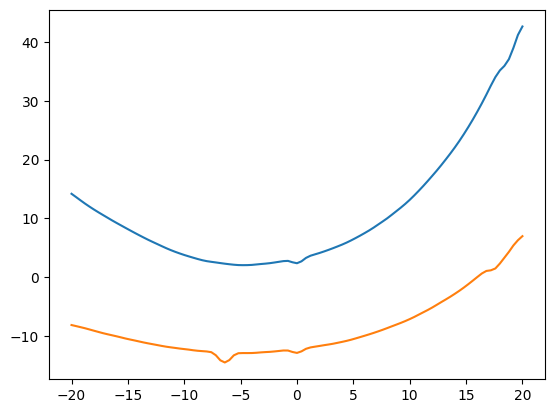

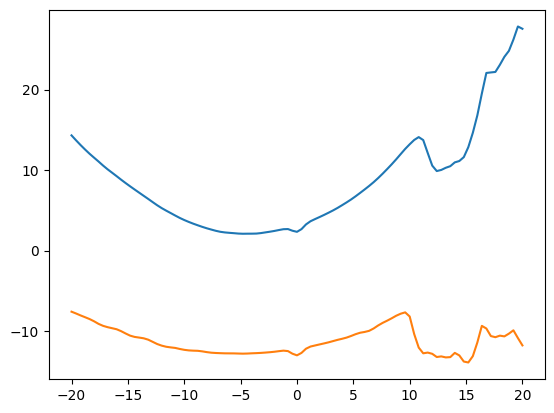

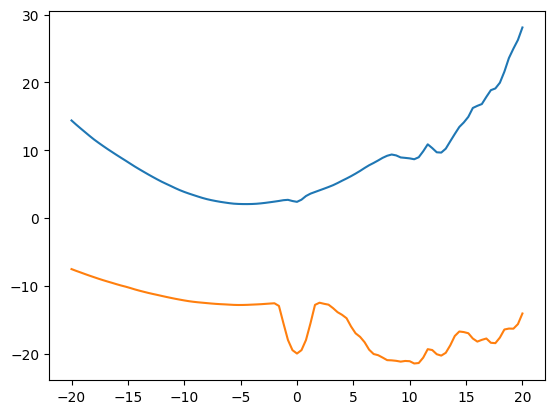

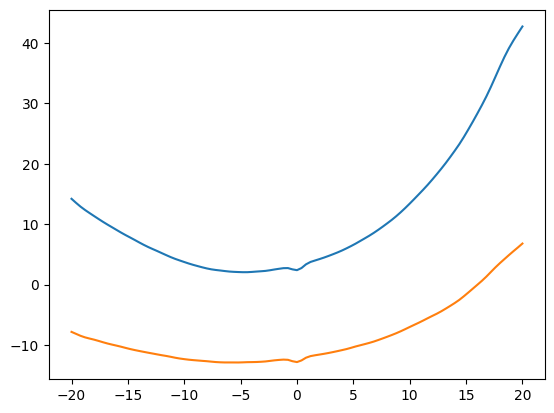

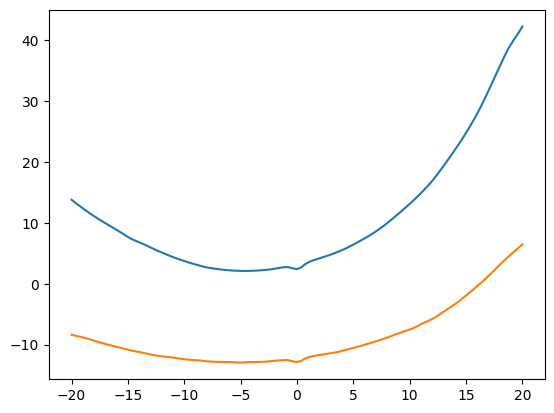

In [5]:
print(config["nt"])
if (not (config["npc"] == None)):
    deltaF = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/deltaF_{config_str}.npy")

    if config["npc"] == 2:
        xcoords = np.linspace(config["sb"], config["eb"], config["nl"])
        ycoords = np.linspace(config["sb"], config["eb"], config["nl"])

        X, Y = np.meshgrid(xcoords, ycoords)

        for i in range(config["nch"]):
            last_delta_F = np.squeeze(deltaF[i, :, :, 9])
            indices = np.unravel_index(np.argmin(last_delta_F), last_delta_F.shape)
            print(deltaF[i, :, :, 0])
            print(f"Chain {i} min deltaF at: {indices}")
            print(xcoords[indices[0]])
            print(ycoords[indices[1]])
            print(f"{i}\n")
            print(last_delta_F[last_delta_F<50])
            plt.figure(figsize=(6,5))
            pcm = plt.pcolormesh(X, Y, last_delta_F.T, shading='auto', cmap='viridis') # This looks flipped, could be the plotting, but could also be the indexing.
            plt.colorbar(pcm, label='Value')
            plt.xlabel('X coordinate')
            plt.ylabel('Y coordinate')
            plt.title('2D Plot with coordinates')
            plt.show()
    if config["npc"] == 1:
        xcoords = np.linspace(config["sb"], config["eb"], config["nl"])
        for i in range(config["nch"]):
            last_delta_F = np.squeeze(deltaF[i, :, :, :])
            plt.plot(xcoords, last_delta_F)
            plt.show()

In [6]:
# starting_points = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/samples_min_dc2.00_a1.50_b0.21_nch4_N50_H100_nlsp24_mi100000_dt0.00_gl0.00.npy")
# starting_energies = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/Emin_dc2.00_a1.50_b0.21_nch4_N50_H100_nlsp24_mi100000_dt0.00_gl0.00.npy")
starting_energies = np.load(f"../../../../output/age_depth_OPES/Emin_{config_find_min_str}.npy")
starting_points = np.load(f"../../../../output/age_depth_OPES/samples_min_{config_find_min_str}.npy")
print(starting_energies)

[ 68.80482717  68.03118086  51.69936735  88.60304103  22.34008739
  56.42709417  83.72710584  22.34324656  68.80207916  84.65756132
  82.10238728  22.34075863 115.16284332  84.1019356   97.57393971
  92.80831238 108.32636237  84.13802189  81.23657785  22.34460124
  83.70409581  83.72544419  22.34091624  22.34198306  76.6071314
  29.10453667  22.34369188  22.34290243  68.79770847  91.88245396
  61.28886542  88.57072449  58.87747607  81.25814742  22.33775279
  76.60682557  22.33400468  62.30115673  51.69446597  22.33538523
 122.688926    51.69503928  87.10356172  22.34006352  22.3370891
  22.34441343  56.52926956  91.42949749  22.34544421  97.57862065
  22.34268015  22.34411336  57.2387536   76.61231273  76.59918038
  74.03670186  84.13493072  39.0636618   22.33632396 100.22237382
  63.64695805  22.34184248  83.99940058  88.57321252  22.34482108
  22.33829047  83.72882381  44.71902989  76.5962106   56.46220232
  22.33370862  22.34196302  68.82024677  57.26210212  56.48740513
 100.2359622

In [7]:
print(starting_points)
# print(np.sort(starting_energies))
sp_mean= np.mean(starting_points, axis = 0)
sp = starting_points-sp_mean
cov = np.cov(sp, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(cov)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

pc1 = eigenvectors[:, 0]
pc2 = eigenvectors[:, 1]

print(eigenvalues)
print(np.sum(eigenvalues[0:4])/np.sum(eigenvalues))
var_ratio = eigenvalues[0] / np.sum(eigenvalues)
var2_ratio = eigenvalues[1] / np.sum(eigenvalues)
print("Main direction at problem:", pc1[20:25])
print(np.abs(pc1) > 0.1)
print("Main direction:", pc1[np.abs(pc1) > 0.1])

print(np.linalg.norm(pc1))
print(30 * np.sum(pc1[pc1>0]))
print(30 * np.sum(pc1[pc1<0]))

[[ 10.11881992  11.58799671   7.53195774  11.42401477  11.23909102
    6.14325174   3.49432061  43.43052633  13.48358012   7.84658838]
 [  3.46450915   0.41598977   0.70658196  24.74112341  33.59619092
   13.16068953  13.54600487  14.66163203  14.5018886    7.27171566]
 [ 10.06597233  11.57264268   7.71065901  10.85105295  21.40078393
   16.14498547   5.37393043   1.90336237  34.63827868   6.21696317]
 [ 10.17618984  11.53649962   5.86398892   1.14894742   9.45144723
    9.98316131   5.55284786  50.73039718  14.4226911    7.22306592]
 [ 10.01525035  11.6535692    7.51283088  10.86389745  22.51347884
   13.76707729  12.88787196  15.1492752   14.34615139   7.6479579 ]
 [ 10.13277979  11.56004386   7.48640624  11.09620366  23.99746131
    9.76800971  32.76288232  13.61610052   1.24701971   3.17574109]
 [ 10.11695276  11.50007489   6.67273551   1.40186235   4.97502779
   23.07743571   3.76999323  43.37060575  13.56551268   7.55783591]
 [ 10.10127623  11.55295169   7.63925252  10.72849305  

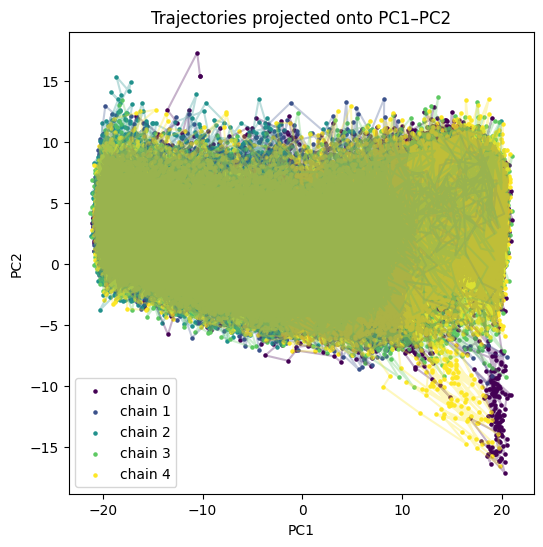

In [8]:
proj = []
for chain in range(samples.shape[0]):
    traj = samples[chain]
    traj_centered = traj - sp_mean
    coords = np.stack([traj_centered @ pc1,
                       traj_centered @ pc2], axis=1) # This should be the same as what i get when i print in C, maybe the indexing becomes wrong when i send in the pcs?
    proj.append(coords)

# Plot
fig, ax = plt.subplots(figsize=(6,6))

for chain, coords in enumerate(proj):
    ax.plot(coords[:,0], coords[:,1], alpha=0.3, color=colors[chain])
    ax.scatter(coords[:,0], coords[:,1], s=5, color=colors[chain], label=f"chain {chain}")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Trajectories projected onto PC1–PC2") # Something is weird, adding the exploration in pc2 makes it explore worse in pc1, something is still wrong.
ax.legend()
plt.show()

In [9]:
print(np.shape(resampled_samples))
print(np.shape(samples))

(5, 100000, 10)
(5, 100000, 10)


In [10]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [11]:
print(energy_values)

[[85.31244895 85.31244895 67.3679992  ... 36.63412743 40.13466122
  41.94471725]
 [32.33469171 30.55732494 35.74934602 ... 32.2126806  32.41144323
  35.19590345]
 [29.06287871 37.26493839 39.90009009 ... 25.74622999 26.58597561
  27.01483101]
 [29.76419603 33.34632754 28.81152022 ... 38.26260518 29.11172174
  27.67024773]
 [31.28648002 28.97423548 39.04792071 ... 37.52425245 40.01843968
  40.46962706]]


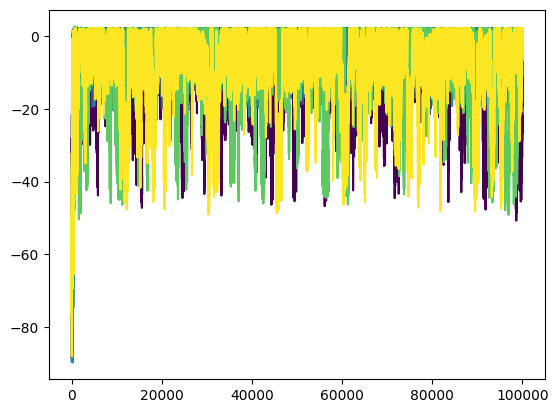

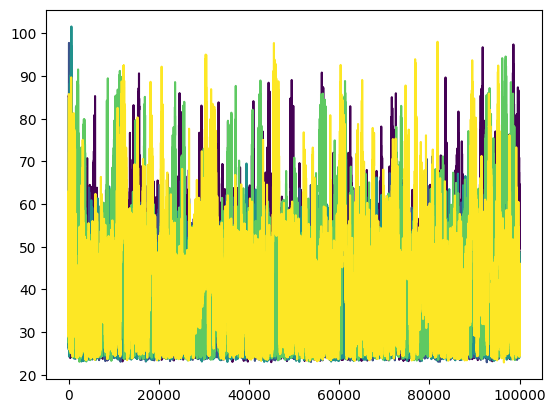

In [12]:
plt.figure()
for i in range(config["nch"]):
    plt.plot(bias_values[i,:], color = colors[i])
plt.show()

plt.figure()
for i in range(config["nch"]):
    plt.plot(energy_values[i,:], color = colors[i])
plt.show()


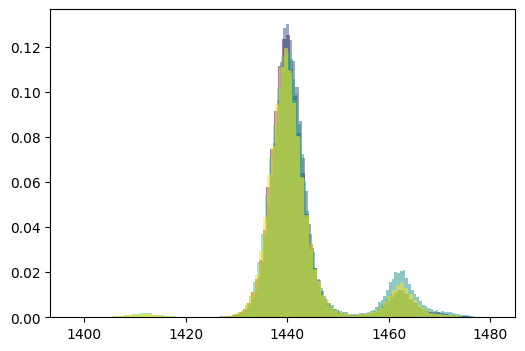

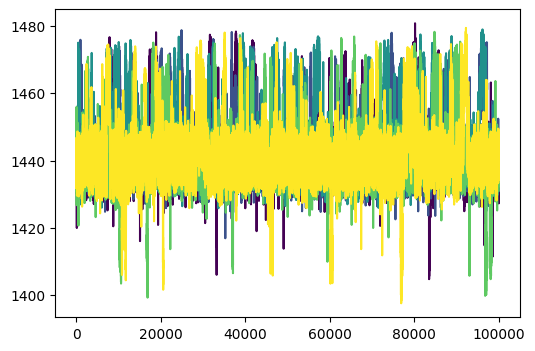

In [37]:
CV_values = data["theta"] - config["dc"] * np.sum(samples[:, :, :4], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
plt.show()

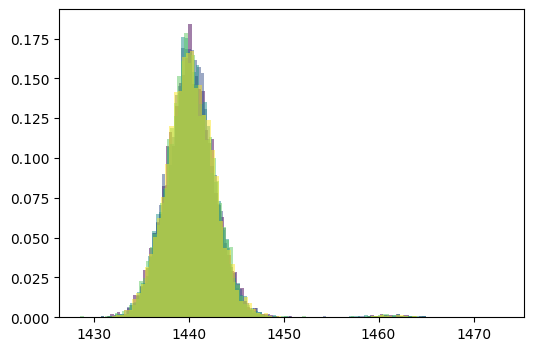

In [27]:
CV_values = data["theta"] - config["dc"] * np.sum(resampled_samples[:, :, :4], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

In [15]:
resampled_samples = resampled_samples[:,::10,:]

In [16]:
print(np.max(bias_values))

2.679366622055709


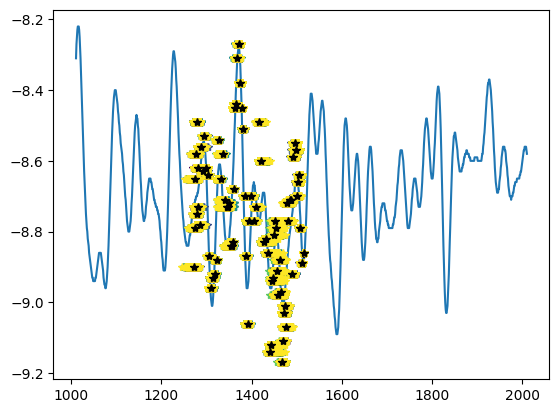

In [17]:
indices = []
for i in range(len(data["d18O_depths"])):
    index = get_index(config["N"], config["cs"], data["d18O_depths"], i)
    indices.append(index)

plt.figure()
plt.plot(data["d18O_reference_times"], data["d18O_reference"])
for i in range(config["nch"]):
    variables = resampled_samples[i,:,:]
    for j in range(len(variables)):
        d18O_ages = expected_ages(config["N"], config["dc"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
        plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
plt.show()

In [18]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(resampled_samples)
summary = az.summary(idata, round_to=2)
print(summary)

       mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]  10.10  1.07    8.23    12.22       0.00     0.00  50878.79  49142.71   
x[1]  11.17  1.90    7.56    14.68       0.01     0.01  51276.86  50146.21   
x[2]   8.26  2.53    3.52    13.09       0.01     0.01  50807.91  49954.37   
x[3]  10.32  2.47    5.76    15.03       0.01     0.01  50539.60  49414.71   
x[4]  22.90  1.82   19.71    25.90       0.01     0.01  50176.43  49338.28   
x[5]  13.49  1.85    9.99    16.86       0.01     0.01  49585.52  49793.26   
x[6]  13.44  2.30    9.16    17.79       0.01     0.01  49067.33  49317.63   
x[7]  14.45  2.42   10.00    19.05       0.01     0.01  48083.91  49195.96   
x[8]  14.93  2.14   10.88    18.89       0.01     0.01  47845.69  48745.37   
x[9]   5.68  3.52    0.15    11.92       0.02     0.01  49458.46  49538.22   

      r_hat  
x[0]    1.0  
x[1]    1.0  
x[2]    1.0  
x[3]    1.0  
x[4]    1.0  
x[5]    1.0  
x[6]    1.0  
x[7]    1.0  
x[8]    1.0  
x

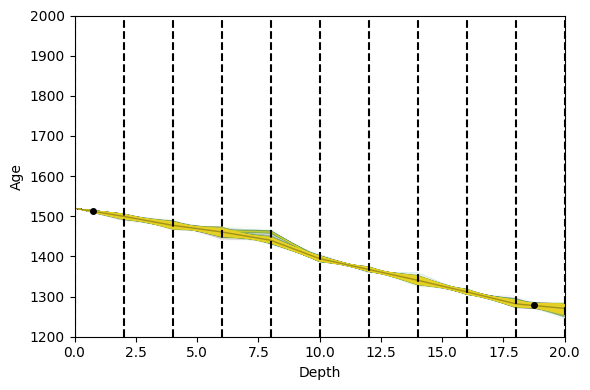

In [24]:
cumulative_sums = np.cumsum(resampled_samples[:, :,:], axis=2) * config["dc"]
zeros = np.zeros((*resampled_samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(resampled_samples[0,:,0])
for i in range(config["nch"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
for i, c in enumerate(config["cs"]):
    ax.axvline(x=c, color='k', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

In [20]:
depths = np.sort(np.hstack((0, data["d18O_depths"])))
ages = np.flip(np.hstack((data["theta"], data["true_ages_D18O"]))) # why are they not sorted correctly?
# print(depths)
# print(ages)
sed_rates = [0]
theta = data["theta"]

pre_age = theta
pre_depth = 0
for i in range(1, config["N"] + 1):
    idx = np.searchsorted(depths, config["cs"][i])
    # print(np.sort(depths))
    # print(config["cs"][i])
    # print(idx)
    if idx < len(depths):
        upper_depth = depths[idx - 1]
        age = ages[idx - 1] + ((ages[idx] - ages[idx - 1])/(depths[idx] - depths[idx - 1]))*(config["cs"][i] - depths[idx-1])
        sed_rates.append((pre_age - age) / (config["cs"][i] - config["cs"][i-1]))
        pre_age = age
    else:
        sed_rates.append(config["a"] / config["b"])


print(sed_rates)
exp_ages = theta - np.cumsum(sed_rates) * config["dc"]
print(exp_ages)
print(np.max(sed_rates))

[0, np.float64(12.17999999999995), np.float64(10.892307692307782), np.float64(8.926892307692242), np.float64(10.811000000000035), np.float64(20.96855000000005), np.float64(13.561249999999973), np.float64(10.768999999999892), np.float64(17.51400000000001), np.float64(13.639500000000112), 7.142857142857143]
[1520.         1495.64       1473.85538462 1456.0016     1434.3796
 1392.4425     1365.32       1343.782      1308.754      1281.475
 1267.18928571]
20.96855000000005


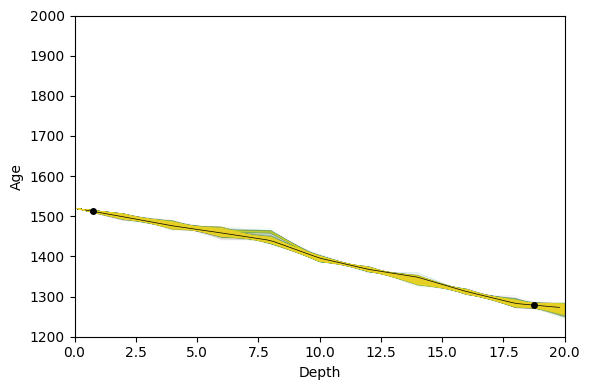

In [23]:
cumulative_sums = np.cumsum(resampled_samples[:, :,:], axis=2) * config["dc"]
zeros = np.zeros((*resampled_samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(resampled_samples[0,:,0])
for i in range(config["nch"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
# for i, c in enumerate(config["cs"]):
#     if i != config["pidx"]:
#         ax.axvline(x=c, color='k', linestyle='--')
#     else:
#         ax.axvline(x=c, color='r', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1200, 2000)
# plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
# plt.plot(config["cs"], exp_ages, color = 'r', linewidth = 0.5)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.plot(data["d18O_depths"], data["true_ages_D18O"], color = 'k', linewidth=0.5)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.show()